In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('default')

In [3]:
df = pd.read_csv('../data/passengers.csv')
df['area'] = df['area'].str.upper()

In [ ]:
#dff_time is a series of the times and their average passenger demand
dff_time=df.groupby('time')['passenger_demand'].mean()
busiest_hour = dff_time[dff_time == dff_time.max()].index[0]
quitest_hour = dff_time[dff_time == dff_time.min()].index[0]

#dff_area is a series of the areas and their average passenger demand
dff_area = df.groupby('area')['passenger_demand'].mean()
busiest_area = dff_area[dff_area == dff_area.max()].index[0]
quitest_area = dff_area[dff_area == dff_area.min()].index[0]

hourly_avg = df.groupby(['area', 'time'], as_index=False)['passenger_demand'].mean()
peak_hourly_avg = hourly_avg.loc[hourly_avg.groupby('area')['passenger_demand'].idxmax()]


,area,time,passenger_demand
5,AJMAN INDUSTRIAL AREA,07:00,149.225718
69,AL BUSTAN,19:30,127.659371
106,AL JURF,18:30,160.904241
147,AL NUAIMIA,19:30,150.779754
164,AL RASHIDIYA,08:30,161.682627
221,AL RAWDA,17:30,111.131327
261,AL ZORAH,18:00,100.502052


column names: 
Index(['Unnamed: 0', 'date', 'day', 'time', 'area', 'bus_route',
       'passenger_demand', 'capacity_limit', 'traffic_delay_mins'],
      dtype='str')

PASSENGER COUNT:

total passegners: 16722382
average passengers: 84

highest passenger count happened on:
2025-09-18, Thursday, 07:00, in AL RASHIDIYA, route E411 with a passenger demand of 225

lowest passenger count happened on:
2024-08-09, Friday, 05:00, in AJMAN INDUSTRIAL AREA, route E411 with a passenger demand of 5

HOUR:

The busiest hour is 19:30 with an average demand of 134
The quitest hour is 05:00 with an average demand of 25

AREA:

The usual busiest area is AL RASHIDIYA
The usual quitest area is AL ZORAH

average demand of each area:

average demand of AJMAN INDUSTRIAL AREA is 94
average demand of AL BUSTAN is 80
average demand of AL JURF is 97
average demand of AL NUAIMIA is 91
average demand of AL RASHIDIYA is 102
average demand of AL RAWDA is 69
average demand of AL ZORAH is 54


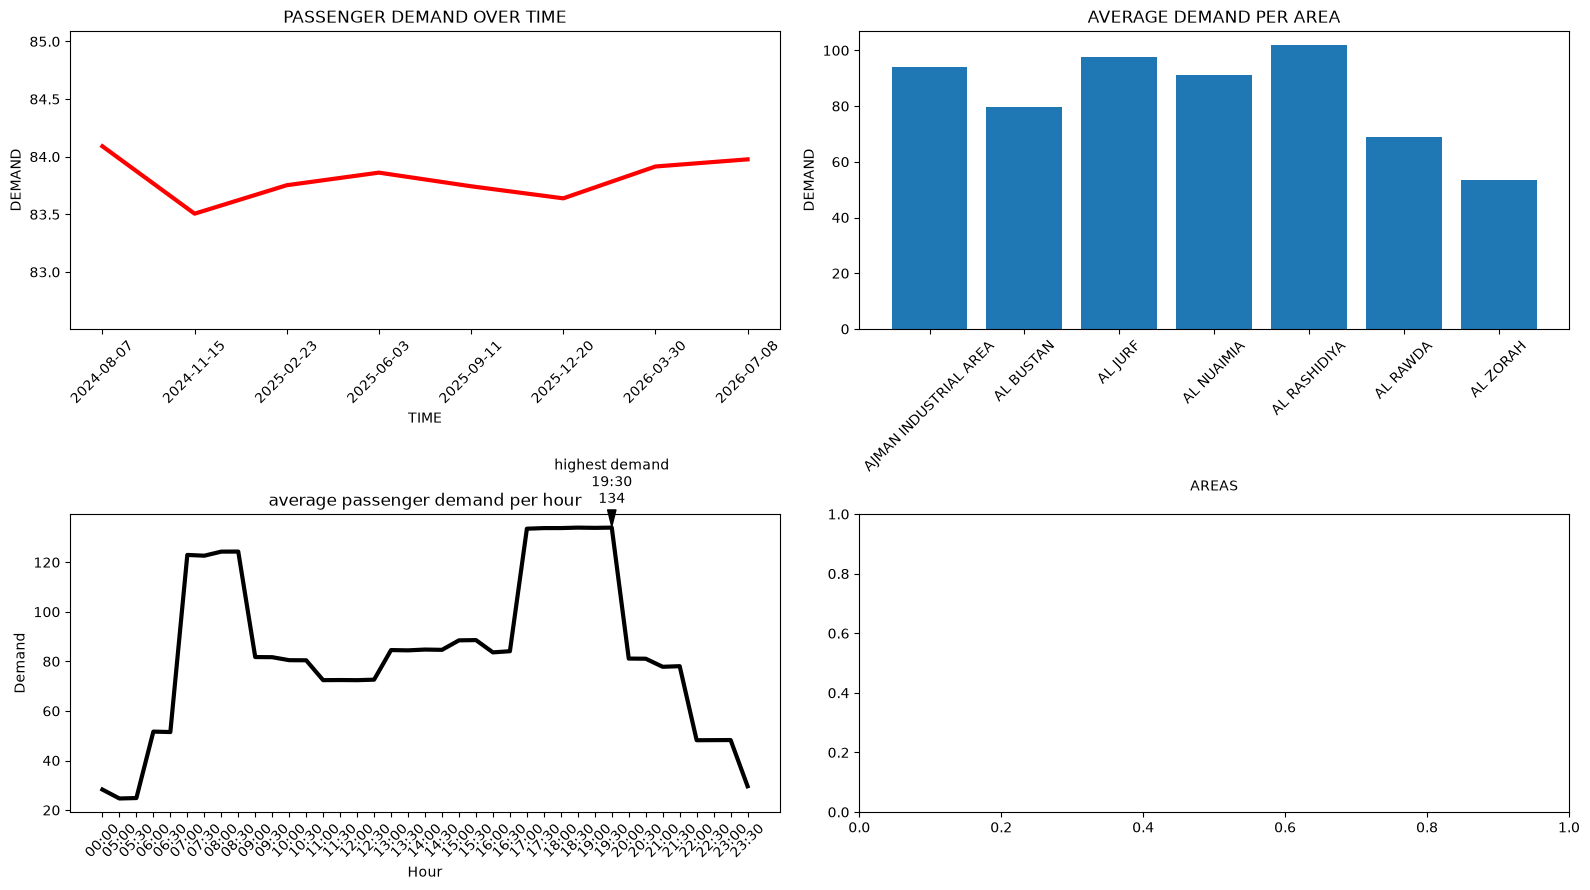

In [8]:
print(f'column names: \n{df.columns}')
print('\nPASSENGER COUNT:\n')
print(f"total passegners: {df['passenger_demand'].sum()}")
print(f"average passengers: {int(df['passenger_demand'].mean().round(0))}\n")
print(f"highest passenger count happened on:\n{df.loc[df['passenger_demand'].idxmax(), 'date']}, {df.loc[df['passenger_demand'].idxmax(), 'day']}, {df.loc[df['passenger_demand'].idxmax(), 'time']}, in {df.loc[df['passenger_demand'].idxmax(), 'area']}, {df.loc[df['passenger_demand'].idxmax(), 'bus_route']} with a passenger demand of {df.loc[df['passenger_demand'].idxmax(), 'passenger_demand']}\n")
print(f"lowest passenger count happened on:\n{df.loc[df['passenger_demand'].idxmin(), 'date']}, {df.loc[df['passenger_demand'].idxmin(), 'day']}, {df.loc[df['passenger_demand'].idxmin(), 'time']}, in {df.loc[df['passenger_demand'].idxmin(), 'area']}, {df.loc[df['passenger_demand'].idxmin(), 'bus_route']} with a passenger demand of {df.loc[df['passenger_demand'].idxmin(), 'passenger_demand']}")
print('\nHOUR:\n')
print(f'The busiest hour is {busiest_hour} with an average demand of {int(dff_time[busiest_hour].round(0))}')
print(f'The quitest hour is {quitest_hour} with an average demand of {int(dff_time[quitest_hour].round(0))}')
print("\nAREA:\n")
print(f'The usual busiest area is {busiest_area}')
print(f'The usual quitest area is {quitest_area}')
print('\naverage demand of each area:\n')
for i in dff_area.index:
    print(f'average demand of {i} is {int(dff_area[i].round(0))}')

#-----------------------------------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
#                                              GRAPH
daily_average = df.groupby('date')['passenger_demand'].mean()
chunked_mean = daily_average.groupby(np.arange(len(daily_average)) // 100).mean()
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16, 9))
ax[0,0].tick_params(axis='x', rotation=45)
ax[0,0].set_xlabel('TIME')
ax[0,0].set_title('PASSENGER DEMAND OVER TIME')
ax[0,0].set_ylabel('DEMAND')
ax[0,0].set_ylim(chunked_mean.min() - 1,chunked_mean.max() + 1)
ax[0,0].plot(daily_average.index[::100], chunked_mean, linewidth=3, color='red')
#---------------------------------------------------------------------------------------------------
ax[0,1].set_xlabel('AREAS')
ax[0,1].set_title('AVERAGE DEMAND PER AREA')
ax[0,1].set_ylabel('DEMAND')
ax[0,1].tick_params(axis='x', rotation=45)
ax[0,1].bar(dff_area.index, dff_area.values)
#---------------------------------------------------------------------------------------------------

ax[1,0].set_title('average passenger demand per hour')
ax[1,0].set_xlabel('Hour')
ax[1,0].set_ylabel('Demand')
ax[1,0].tick_params(axis='x', rotation=45)
ax[1,0].annotate(
    f'highest demand\n{busiest_hour}\n{int(dff_time[busiest_hour].round(0))}',
    xy=(busiest_hour, dff_time[busiest_hour]),
    xytext=(busiest_hour, dff_time[busiest_hour] + 10),
    ha='center',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6)
)
ax[1,0].plot(dff_time, color='black', lw=3)
#---------------------------------------------------------------------------------------------------

# FIX: Saved math coordinates to hour_num instead of destroying the text 'time' column


# bars = ax[1, 1].bar(
#     peak_hourly_avg['area'], 
#     peak_hourly_avg['hour_num'], # FIX: Use numeric height for drawing
#     color='lightgreen', 
#     edgecolor='green'
# )
# ax[1, 1].set_title('Peak Bus Demand Time')
# ax[1, 1].set_xlabel('Areas')
# ax[1, 1].set_ylabel('Hour of Day (24h Clock)')
# ax[1, 1].set_ylim(0, 24)
# ax[1,1].tick_params(axis='x', rotation=45)
# for bar, original_time in zip(bars, peak_hourly_avg['time']):
#     bar_height = bar.get_height()
#     bar_x_position = bar.get_x()
#     bar_width = bar.get_width()
#     center_of_bar = bar_x_position + (bar_width / 2)
#     ax[1, 1].text(
#         x=center_of_bar, 
#         y=bar_height + 0.5, 
#         s=original_time, 
#         ha='center'
#     )
plt.tight_layout()

In [ ]:
df['time']

0         05:00
1         05:00
2         05:00
3         05:00
4         05:00
          ...  
199558    00:00
199559    00:00
199560    00:00
199561    00:00
199562    00:00
Name: time, Length: 199563, dtype: str